In [1]:
import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt

# import pydot
# import graphviz
import math
# from matplotlib import cm
# from matplotlib.ticker import LinearLocator

import time
import random

In [2]:
tf.keras.backend.set_floatx('float64')

In [3]:
a = 2/3
b = 4/3
c = 1
d = 1

In [4]:
def rklv(u, t_start, t_end, t_step_size) :
    
    [x0, y0] = u

    def rk4(r, t, h):                    #edited; no need for input f
            """ Runge-Kutta 4 method """
            k1 = h*f(r, t)
            k2 = h*f(r+0.5*k1, t+0.5*h)
            k3 = h*f(r+0.5*k2, t+0.5*h)
            k4 = h*f(r+k3, t+h)
            return (k1 + 2*k2 + 2*k3 + k4)/6

    def f(r, t):
            x, y = r[0], r[1]
            fxd = a*x - b*x*y
            fyd = c*x*y - d*y
            return np.array([fxd, fyd], float)

    h=t_step_size                               #edited
    tpoints = np.arange(t_start, t_end + h, h)         #edited
    xpoints, ypoints  = [], []
    r = np.array([x0, y0], float)
    for t in tpoints:
            xpoints.append(r[0])          #edited
            ypoints.append(r[1])          #edited
            r += rk4(r, t, h)             #edited; no need for input f
            
#     plt.plot(xpoints, ypoints)
#     plt.xlabel("x")
#     plt.ylabel("y")
#     plt.show()

    tarr = np.asarray(tpoints)
    xarr = np.asarray(xpoints)
    yarr = np.asarray(ypoints)

    points = np.vstack((tarr, xarr, yarr))

    return points

In [5]:
rklv([0.9, 0.9], 0, 12, 0.01)

array([[0.00000000e+00, 1.00000000e-02, 2.00000000e-02, ...,
        1.19800000e+01, 1.19900000e+01, 1.20000000e+01],
       [9.00000000e-01, 8.95218232e-01, 8.90473056e-01, ...,
        9.40336324e-01, 9.43622908e-01, 9.46922674e-01],
       [9.00000000e-01, 8.99078926e-01, 8.98116013e-01, ...,
        2.38393190e-01, 2.38254911e-01, 2.38124554e-01]])

In [6]:
def define_collocation_points(t_bdry, N_points=100):

    colloc_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_points)

    return colloc_points

In [7]:
M = 2
N = 2
P = 101


t0 = 0.0
tfinal = 10.0
t_step = 0.01

In [8]:
def build_model(num_layers = 4, num_units = 60, summary = False) :
    
    inp_br_init = br = tf.keras.layers.Input(shape = (2,), name = "Input_br_init")
    
    for i in range(num_layers) :
        
        br = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_br_" + str(i))(br)
        
    out_br_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_x")(br)
    out_br_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_br_y")(br)
    
    
    inp_tr = tr = tf.keras.layers.Input(shape = (1,), name = "Input_tr")
    
    for i in range(num_layers) :
        
        tr = tf.keras.layers.Dense(num_units, activation = 'tanh', name = "Hidden_tr_" + str(i))(tr)
        
    out_tr_x = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_x")(tr)
    out_tr_y = tf.keras.layers.Dense(1, activation = 'linear', name = "output_tr_y")(tr)

    mult_x = tf.keras.layers.Multiply(name = "multiply_x")([out_br_x, out_tr_x])
    mult_y = tf.keras.layers.Multiply(name = "multiply_y")([out_br_y, out_tr_y])
    
    out_x = tf.keras.layers.Dense(1, name = "output_x")(mult_x)
    out_y = tf.keras.layers.Dense(1, name = "output_y")(mult_y)
    
    model = tf.keras.models.Model([inp_br_init, inp_tr], [out_x, out_y])
    
    if summary :
        
        model.summary()
        
    return model

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input_br_init (InputLayer)     [(None, 2)]          0           []                               
                                                                                                  
 Input_tr (InputLayer)          [(None, 1)]          0           []                               
                                                                                                  
 Hidden_br_0 (Dense)            (None, 60)           180         ['Input_br_init[0][0]']          
                                                                                                  
 Hidden_tr_0 (Dense)            (None, 60)           120         ['Input_tr[0][0]']               
                                                                                              

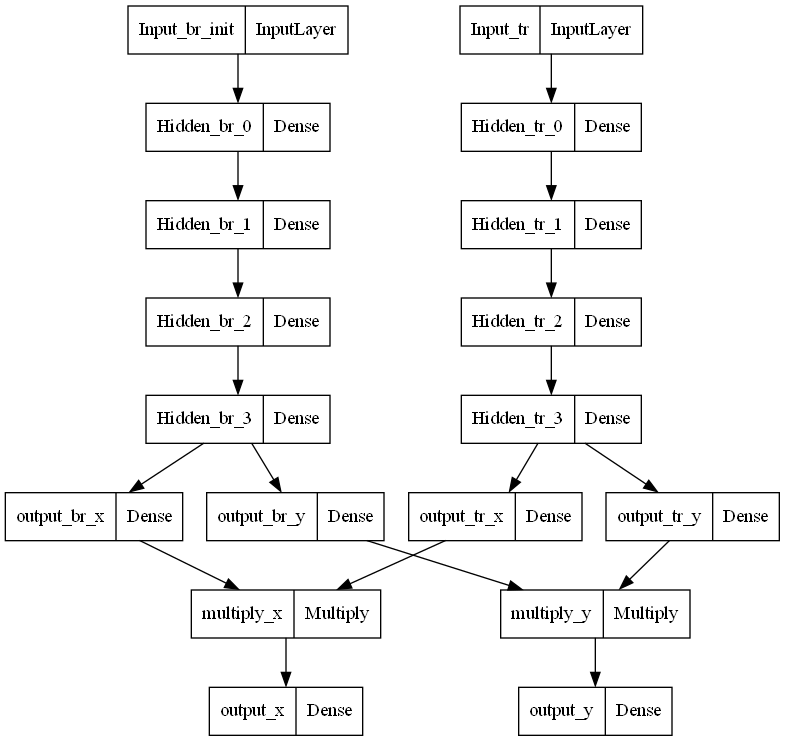

In [9]:
model = build_model(summary = True)
tf.keras.utils.plot_model(model, to_file = 'DeepOnet.png')

In [10]:
u_data = np.random.rand(N, M)

In [11]:
def clone_u_data (data) :
    
    new_data = np.zeros((N*P, M))
    
    for i in range(N) :
        
        data_row = data[i]
        
        cloned_data = np.tile(data_row, (P,1))
        
        new_data[i*P:(i + 1)*P, :] = cloned_data
        
    return new_data

In [12]:
def clone_t_data (data) :
    
    new_data = np.tile(data, (N,1))
    
    return new_data

In [13]:
u_data = clone_u_data(u_data)
u_train = u_data

Text(0.5, 1.0, 'Collocation points being used')

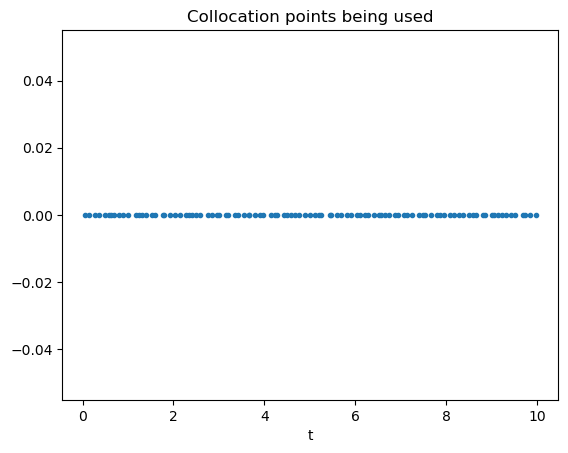

In [14]:
colloc = define_collocation_points([t0, tfinal], P)
plt.plot(colloc[:,0], 0 * colloc[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')

In [15]:
t_init = np.zeros((N*P, 1))

In [16]:
decimal_p = int((np.floor(np.log10(1/t_step))))
print(decimal_p)

2


In [17]:
t_data = colloc
t_data = clone_t_data(t_data)

t_data = np.around(t_data, decimal_p)
t_train = t_data

In [18]:
true_data = np.zeros((N*P, 2))

for i in range(N*P) :
    
    u = u_train[i]
    t = t_train[i]
    
    sol_points = rklv(u, t0, tfinal, t_step)
    
    t_sol = sol_points[0]
    t_sol = np.around(t_sol, decimal_p)
    
    x_sol = sol_points[1]
    y_sol = sol_points[2]
    
    index = np.where(t_sol == t)
    
    true_data[i][0] = x_sol[index][0]
    true_data[i][1] = y_sol[index][0]
    
print(true_data.shape)

(202, 2)


In [19]:
u_train[:, :2] = np.log(u_train[:, :2])
true_data = np.log(true_data)

In [20]:
# The main training function
@tf.function
def train_network(model, u_cond, t, x_true, y_true, x_init, y_init, V, alpha, beta, gamma, delta):

    with tf.GradientTape() as tape1:

        with tf.GradientTape(persistent=True) as tape2:
            
            tape2.watch(t)
            [x, y] = model([u_cond, t], training=True)

        xt = tape2.gradient(x, t)
        yt = tape2.gradient(y, t)
        
        xt = tf.reshape(xt, [N*P, 1])
        yt = tf.reshape(yt, [N*P, 1])
 
        Gloss = tf.reduce_mean(tf.square(x - x_true) + tf.square(y - y_true))
        
        eqn1 = xt - a + b*(tf.math.exp(y))
        eqn2 = yt - c*(tf.math.exp(x)) + d
        print("eqn1", eqn1)
        print("eqn2", eqn2)
        DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
        [x_init_pred, y_init_pred] = model([u_cond, t_init], training=True)
        
        print("x_init", x_init)
        print("x_init", x_init)
        print("x_init_pred", x_init_pred)
        print("y_init_pred", y_init_pred)
        print("x", x)
        print("y", y)
        
        IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
        v = (c * (tf.math.exp(x))) - (d * x) + (b * tf.math.exp(y)) - (a * y)
    
        Vloss = tf.reduce_mean(tf.square(v - V))
        
        loss = beta*DEloss + gamma*IVloss + delta*Vloss

    grads = tape1.gradient(loss, model.trainable_variables)
    
    return DEloss, IVloss, Vloss, grads

In [21]:
def DeepONet_train(model, u, t, G_true, epochs, alpha_val, beta_val, gamma_val, delta_val):

    lr_model = 1e-3
    
    alpha = alpha_val
    beta = beta_val
    gamma = gamma_val
    delta = delta_val
    
    u_cond = u
    
    x_init = u[:, 0].reshape(-1, 1)
    y_init = u[:, 1].reshape(-1, 1)
    
    
    V = (c * (np.exp(x_init))) - (d * x_init) + (b * np.exp(y_init)) - (a * y_init)
      
    x_true = G_true[:, 0].reshape(-1, 1)
    y_true = G_true[:, 1].reshape(-1, 1)
    
    print(u_cond.shape, x_init.shape, y_init.shape, V.shape, x_true.shape, y_true.shape)

    epoch_loss = np.zeros(epochs)
    
    opt = tf.keras.optimizers.Adam(lr_model)

    for i in range(epochs):

        DEloss, IVloss, Vloss, grads = train_network(model, u_cond, t, x_true, y_true, x_init, y_init, V,
                                                     alpha, beta, gamma, delta)

        opt.apply_gradients(zip(grads, model.trainable_variables))
      
        epoch_loss[i] += beta*DEloss + gamma*IVloss + delta*Vloss

    
        if (np.mod(i, 100)==0):
       
            print("DE loss, IV loss, Vloss in {}th epoch: {: 6.4f}, {: 6.4f}, {: 6.4f}.".format(
                i, DEloss, IVloss, Vloss))

    return epoch_loss, model

In [22]:
alpha = 0.0
beta = 12
gamma = 1.2
delta = 100

epochs = 100000

In [23]:
model = build_model()

loss, model = DeepONet_train(model, u_train, t_train, true_data, epochs, alpha, beta, gamma, delta)

(202, 2) (202, 1) (202, 1) (202, 1) (202, 1) (202, 1)
eqn1 Tensor("add_1:0", shape=(202, 1), dtype=float64)
eqn2 Tensor("add_2:0", shape=(202, 1), dtype=float64)
x_init Tensor("x_init:0", shape=(202, 1), dtype=float64)
x_init Tensor("x_init:0", shape=(202, 1), dtype=float64)
x_init_pred Tensor("model_1/output_x/BiasAdd_1:0", shape=(202, 1), dtype=float64)
y_init_pred Tensor("model_1/output_y/BiasAdd_1:0", shape=(202, 1), dtype=float64)
x Tensor("model_1/output_x/BiasAdd:0", shape=(202, 1), dtype=float64)
y Tensor("model_1/output_y/BiasAdd:0", shape=(202, 1), dtype=float64)
DE loss, IV loss, Vloss in 0th epoch:  0.3880,  6.1628,  0.7605.
DE loss, IV loss, Vloss in 100th epoch:  1.2694,  4.5499,  0.0286.


KeyboardInterrupt: 

In [ ]:
test_u = np.array([0.9, 0.9])
test_t = np.arange(0, tfinal + t_step, t_step)

sol = rklv(test_u, t0, tfinal, t_step)
x_sol = sol[1]
y_sol = sol[2]

test_u = np.tile(test_u, (len(test_t),1))
test_u_cond = np.log(test_u)

print(test_u_cond.shape)
print(test_t.shape)

In [ ]:
[test_x, test_y] = model([test_u_cond, test_t], training=True)

test_x = np.exp(test_x)
test_y = np.exp(test_y)

plt.figure()
plt.plot(test_x, test_y)
plt.plot(x_sol, y_sol)

In [ ]:
test_x = np.array([[2, 7, 5, 8, 9,4]]).reshape(-1, 1)
test_y = np.array([[2, 7, 5, 8, 9,4]]).reshape(-1, 1)
x_sol = np.array([[2, 7, 5, 8, 9,4]]).reshape(-1, 1)
y_sol = np.array([[2, 7, 5, 8, 9,4]]).reshape(-1, 1)

print(test_x.shape)
mse = ((test_x - x_sol)**2 + (test_y - y_sol)**2).mean(axis=0)
print(mse)